# Chapter 5: Sig-WGAN - Signature-Based Wasserstein GANs

**Chapter 5: Synthetic Data Generation**
**Section Reference**: Section 5.4 (GANs for Time Series)

**Docker image**: `ml4t-gpu`

> **Docker required**: This notebook uses `signatory` and `esig`, which are x86-only
> packages not included in the default environment. Run with:
> ```bash
> docker compose --profile py312 run --rm py312 python 05_synthetic_data/03_sigcwgan_signatures.py
> ```

## Purpose

This notebook implements the **unconditional Sig-Wasserstein GAN** — the core of
Sig-CWGAN (Ni et al., Mathematical Finance 2024) — which uses **path signatures**
as a principled distance metric for comparing time-series distributions. We build
and train the unconditional variant; the conditional extension P(future | past) is
explained conceptually but not implemented here.

## Learning Objectives

By completing this notebook, you will:
- Transform financial time series into path signatures using the `signatory` library
- Implement an (unconditional) Sig-Wasserstein GAN that matches expected signatures
- Use the expected signature (Sig-W1) as the training objective instead of a
  trained discriminator
- **Understand how the conditional Sig-CWGAN extends this** with a Monte Carlo
  expected-signature objective (the key paper insight; the conditional path is
  described, not built, in this notebook)
- Evaluate generative fidelity using signature-based metrics and TSTR

## Cross-References

- **Upstream**: ETF Universe loader (`data`)
- **Downstream**: Conditional generation for scenario analysis
- **Book**: Section 5.2 discusses signature-based methods

---

## The Evolution from TimeGAN

TimeGAN (2019) introduced embedding spaces and stepwise supervision. But its
discriminator still uses a binary classifier to distinguish real/fake - which
doesn't provide a smooth gradient landscape for generator training.

Sig-CWGAN (2020→2024) introduces two innovations:

1. **Signature Distance**: Instead of a trained discriminator, use the
   **expected signature** to characterize time series distributions. The
   signature is a universal feature set that uniquely identifies probability
   measures on path space.

2. **Conditional W1 Metric** (the paper's full method): learn the conditional
   distribution P(future | past) rather than the unconditional law — more useful
   for finance (given what happened yesterday, what might happen tomorrow?). This
   notebook implements the unconditional Sig-W1 core; the conditional metric is
   described here but left as an extension.

## What Are Path Signatures?

The signature of a path is an infinite series of iterated integrals that
completely characterizes the path up to reparameterization:

```
Sig(X)_t = (1, ∫dX_s, ∫∫dX_s⊗dX_u, ∫∫∫dX_s⊗dX_u⊗dX_v, ...)
```

**Key Properties**:
- **Uniqueness**: The expected signature E[Sig(X)] uniquely determines
  the law of the stochastic process X (under mild conditions)
- **Universality**: Any continuous function of paths can be approximated
  by a linear function of the signature
- **Computability**: Truncated signatures are tractable to compute

## Architecture Overview

Sig-CWGAN consists of three main components:
1. **Path Augmentation**: Transform raw returns into signature-ready paths
2. **Signature Computation**: Compute truncated path signatures
3. **AR-FNN Generator**: Autoregressive feedforward network conditioned on past

See `figures/figure_5_10_sigcwgan_architecture.png` for the full architecture diagram.

**Key Insight**: The loss is on **expected signatures**, not single-sample signatures.
For each past, we generate m futures with different noise, compute their signatures,
and average before comparing to the target. This is the core Sig-CWGAN algorithm.

## References

- **Paper**: Ni, H., Szpruch, L., Wiese, M., Liao, S., & Xiao, B. (2024).
  "Sig-Wasserstein GANs for Conditional Time Series Generation."
  Mathematical Finance, 34(4), 1179-1227.
  https://onlinelibrary.wiley.com/doi/full/10.1111/mafi.12423
- **ArXiv (2020)**: https://arxiv.org/abs/2006.05421
- **Code**: https://github.com/SigCGANs/Conditional-Sig-Wasserstein-GANs

---

## Paper-Exact Data Source

**This notebook now uses the EXACT same data as the paper**:
- **Source**: S&P 500 index daily close prices
- **Returns**: Log returns: `log(close_t) - log(close_{t-1})`
- **Period**: 2005-01-01 to 2020-06-01 (paper period)
- **Single asset**: Paper uses `.SPX` only (not multiple assets)

The original paper used Oxford MAN Realized Library (now defunct), which
provided the same S&P 500 index prices, loaded via `load_sp500_index()`.

## WARNING: Signature Dimension Scaling

Signature dimension scales as O(d^depth) where d = feature count after augmentations.

| Assets | After Augmentations | Depth 4 Sig Dim | Feasibility |
|--------|---------------------|-----------------|-------------|
| 1      | 5 features          | 780 dims        | [OK] Fast      |
| 2      | 7 features          | 2,800 dims      | [OK] Feasible  |
| 5      | 13 features         | 30,940 dims     | WARNING: Slow     |
| 10     | 23 features         | 303,600 dims    | [FAIL] OOM       |

**This notebook uses 1 asset (S&P 500) to match the paper exactly.**

In [1]:
"""Sig-CWGAN — Signature-based conditional Wasserstein GAN for time series generation."""

import json
import math
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim

## Sig-CWGAN Architecture

The architecture uses path signatures as an analytic discriminator, replacing
trained neural networks with a mathematically principled distance metric.

In [2]:
from IPython.display import Image, display
from plotly.subplots import make_subplots
from scipy import stats
from tqdm import tqdm

from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

ASSETS_DIR = get_chapter_dir(5) / "assets"
if (ASSETS_DIR / "sigcwgan_architecture.jpeg").exists():
    display(Image(ASSETS_DIR / "sigcwgan_architecture.jpeg", width=800))

# Checkpoint path for model persistence
CHECKPOINT_PATH = get_output_dir(5, "sigcwgan") / "checkpoints" / "sigcwgan_model.pt"

In [3]:
N_LAGS = 16  # Path length (paper: 16)
SIG_DEPTH = 4  # Signature truncation depth (paper: 4)
LSTM_HIDDEN_DIM = 50  # LSTM hidden dimension
LSTM_N_LAYERS = 2  # LSTM layers
TOTAL_STEPS = 2500  # Gradient steps (paper: 2500)
BATCH_SIZE = 2000  # Batch size (paper: 2000)
MC_SAMPLES_TRAIN = 16  # Monte Carlo samples during training
MC_SAMPLES_EVAL = 500  # Monte Carlo samples during evaluation
RETRAIN = False  # Set True to force retraining even if checkpoint exists
SEED = 42

In [4]:
set_global_seeds(SEED)

In [5]:
# =============================================================================
# SIGNATURE LIBRARY SETUP
# =============================================================================
# SigCWGAN training requires differentiable path signatures (autograd support).
# signatory provides GPU-accelerated differentiable signatures.
# Install: pip install --no-build-isolation signatory (requires torch first).
# =============================================================================

import signatory

In [6]:
def compute_signature_gpu(paths: torch.Tensor, depth: int) -> torch.Tensor:
    """Compute signatures on GPU (differentiable)."""
    return signatory.signature(paths, depth)

In [7]:
def compute_signature_np(path: np.ndarray, depth: int) -> np.ndarray:
    """Compute signature of a single path (numpy)."""
    path_tensor = torch.tensor(path, dtype=torch.float32).unsqueeze(0)
    sig = signatory.signature(path_tensor, depth)
    return sig.squeeze(0).numpy()

### Configuration (Ni et al., Mathematical Finance 2024)

Following the original paper exactly:
- `configs/STOCKS/SigWGAN.json` specifies the exact settings
- LSTMGenerator with Brownian motion noise input
- Augmentations: Scale(2, dim=0) &rarr; AddTime &rarr; LeadLag &rarr; VisiTrans("I")
- Factorial normalization on signature levels
- batch_size=2000, depth=4, lr=1e-3, n_gradient_steps=2500

**Data source**: S&P 500 index daily close prices (matching Oxford MAN source).
Paper uses log returns of close prices for a single asset (.SPX),
period 2005-01-01 to 2020-06-01.

Signature dimension scales as $O(d^{\text{depth}})$ where $d$ is the feature count.
With depth=4 and proper augmentations, we match the paper's methodology.

In [8]:
CONFIG = {
    # Data - PAPER EXACT: Single asset (S&P 500), log returns
    "data_source": "sp500",  # Use bundled S&P 500 index data
    "start_date": "2005-01-01",  # Paper start date
    "end_date": "2020-06-01",  # Paper end date (for training)
    "holdout_start": "2018-01-01",  # Our holdout for TSTR evaluation
    # Paper uses n_lags=16 for path length
    "n_lags": N_LAGS,
    # Signature - PAPER USES DEPTH 4
    "sig_depth": SIG_DEPTH,
    # Architecture - PAPER USES LSTM GENERATOR
    "lstm_hidden_dim": LSTM_HIDDEN_DIM,
    "lstm_n_layers": LSTM_N_LAYERS,
    "noise_dim": 1,  # Single asset (paper convention: noise_dim = input_dim)
    # Training - MATCH PAPER EXACTLY
    "total_steps": TOTAL_STEPS,
    "batch_size": BATCH_SIZE,
    "learning_rate": 1e-3,  # Paper: 1e-3 (NOT 1e-2)
    "lr_scheduler_step": 128,  # Paper: StepLR(128, 0.95)
    "lr_scheduler_gamma": 0.95,
    # Augmentations (from configs/STOCKS/SigWGAN.json)
    "scale_factor": 2.0,
    "scale_dim": 0,
    # MC samples for expected signature (conditional version)
    "mc_samples_train": MC_SAMPLES_TRAIN,
    "mc_samples_eval": MC_SAMPLES_EVAL,
    # Factorial normalization (CRITICAL - paper uses this)
    "normalise_sig": True,
}

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Integrity and TSTR Methodology

**Critical**: This notebook implements a proper train/holdout split to enable
unbiased Train-Synthetic-Test-Real (TSTR) evaluation.

### Normalization: Preserving Sign (CRITICAL)

**IMPORTANT**: We use z-score normalization (mean 0, std 1), NOT MinMax to [0,1].

Why? The path signature uses cumulative sums. If returns are mapped to [0,1],
every coordinate becomes monotonically increasing - the path can only "go up".
This destroys the sign structure of returns, which is essential for meaningful
financial paths and signatures.

```
WRONG:  returns ∈ [0,1] → cumsum always increases → no "down" moves
RIGHT:  returns ∈ ℝ (centered) → cumsum goes up and down → realistic paths
```

## 1. Load Financial Data

**PAPER-EXACT DATA SOURCE**: S&P 500 index daily close prices

The paper uses the Oxford MAN Realized Library which provided S&P 500 index
prices (now defunct). We use bundled S&P 500 data which is equivalent.

**Key difference from previous implementation**:
- **Before**: ETF percent returns (SPY, QQQ)
- **Now**: S&P 500 index LOG returns (single asset, paper-exact)

In [10]:
def load_sp500_log_returns(
    start_date: str, end_date: str | None = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Load S&P 500 index LOG returns (PAPER-EXACT).

    The paper uses: log(close_t) - log(close_{t-1})
    NOT percent returns: (close_t - close_{t-1}) / close_{t-1}

    For small returns these are nearly identical, but log returns have
    nicer properties (additive over time, symmetric).

    Args:
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD), or None for all data

    Returns:
        Tuple of (log_returns, timestamps) where:
        - log_returns: np.ndarray of shape (n_days, 1)
        - timestamps: np.ndarray of datetime64 timestamps
    """
    from data import load_sp500_index

    df = load_sp500_index()

    start_dt = pl.lit(start_date).str.to_date()
    df = df.filter(pl.col("timestamp") >= start_dt)

    if end_date is not None:
        end_dt = pl.lit(end_date).str.to_date()
        df = df.filter(pl.col("timestamp") <= end_dt)

    df = df.sort("timestamp")

    # Compute LOG returns (PAPER-EXACT)
    # log(close_t) - log(close_{t-1}) = log(close_t / close_{t-1})
    df = df.with_columns(pl.col("close").log().diff().alias("log_return")).drop_nulls()

    timestamps = df.select("timestamp").to_numpy().flatten()
    log_returns = df.select("log_return").to_numpy().astype(np.float32)

    print(f"Loaded {len(log_returns)} days of S&P 500 LOG returns")
    print(f"Date range: {timestamps[0]} to {timestamps[-1]}")
    print("Return type: LOG returns (paper-exact)")

    return log_returns, timestamps


all_returns, all_timestamps = load_sp500_log_returns(CONFIG["start_date"], CONFIG.get("end_date"))
n_total_days, n_assets = all_returns.shape
print(f"Data shape: {all_returns.shape} (days, assets)")
print(f"Number of assets: {n_assets} (paper uses 1 = S&P 500 only)")

# CRITICAL: Split at holdout_start date
holdout_dt = np.datetime64(CONFIG["holdout_start"])
train_mask = all_timestamps < holdout_dt

returns_train_raw = all_returns[train_mask]
holdout_returns_raw = all_returns[~train_mask]
train_timestamps = all_timestamps[train_mask]
holdout_timestamps = all_timestamps[~train_mask]
n_days = len(returns_train_raw)

print("\nTSTR Data Split (temporal at holdout_start):")
print(
    f"  Training:  {len(returns_train_raw):,} days ({train_timestamps[0]} to {train_timestamps[-1]})"
)
print(
    f"  Holdout:   {len(holdout_returns_raw):,} days ({holdout_timestamps[0]} to {holdout_timestamps[-1]})"
)
print("\nPaper reference period: 2005-01-01 to 2020-06-01 (~3,800 days)")

# =============================================================================
# PAPER-EXACT: NO NORMALIZATION
# =============================================================================
# The paper uses RAW log returns without any normalization.
# Daily log returns are tiny (~0.001), which keeps signature values small.
# This is critical for matching the paper's Sig-W1 values (~2.76).
# =============================================================================

# Use raw log returns (NO z-score normalization - paper-exact)
returns = returns_train_raw
holdout_returns = holdout_returns_raw

# Store statistics for reference (but don't apply normalization)
train_mean = returns_train_raw.mean(axis=0)
train_std = returns_train_raw.std(axis=0)

print("\nUsing RAW log returns (paper-exact, no normalization):")
print(f"  Mean: {train_mean[0]:.6f}")
print(f"  Std: {train_std[0]:.6f}")
print(f"  Range: [{returns.min():.6f}, {returns.max():.6f}]")
print("  NOTE: Paper uses raw log returns to keep signature magnitudes small")

# Keep original scale for output
returns_original = returns_train_raw
holdout_returns_original = holdout_returns_raw

Loaded 3871 days of S&P 500 LOG returns
Date range: 2005-01-04 to 2020-06-01
Return type: LOG returns (paper-exact)
Data shape: (3871, 1) (days, assets)
Number of assets: 1 (paper uses 1 = S&P 500 only)

TSTR Data Split (temporal at holdout_start):
  Training:  3,264 days (2005-01-04 to 2017-12-29)
  Holdout:   607 days (2018-01-02 to 2020-06-01)

Paper reference period: 2005-01-01 to 2020-06-01 (~3,800 days)

Using RAW log returns (paper-exact, no normalization):
  Mean: 0.000245
  Std: 0.011910
  Range: [-0.094695, 0.109572]
  NOTE: Paper uses raw log returns to keep signature magnitudes small


## 2. Path Augmentation and Signature Computation

Raw return paths need **augmentation** before signature computation.

**PAPER PIPELINE** (configs/STOCKS/SigWGAN.json):
1. **Scale(2, dim=0)**: Scale first dimension by 2
2. **AddTime**: Prepend time coordinate [0,1]
3. **LeadLag**: Lead-lag transform for quadratic variation
4. **VisiTrans("I")**: I-visibility transform (adds 2 rows + 1 column)

**CRITICAL**: Our previous implementation used cumsum_concat + lag_added,
which is NOT what the paper uses. The paper's augmentations are specifically
designed for their signature-based loss.

The signature depth of 4 with these augmentations matches the paper methodology.

In [11]:
# =============================================================================
# PAPER-EXACT PATH TRANSFORMS (from lib/augmentations.py)
# =============================================================================
# These transforms MUST match the paper exactly for comparable results.
# Reference: configs/STOCKS/SigWGAN.json
# =============================================================================


def scale_transform(path: np.ndarray, scale: float = 2.0, dim: int = 0) -> np.ndarray:
    """
    Scale a specific dimension of the path.

    Paper config: {"name": "Scale", "scale": 2, "dim": 0}

    Args:
        path: Shape (seq_len, d) or (batch, seq_len, d)
        scale: Scaling factor
        dim: Dimension to scale (0 = first asset)

    Returns:
        Scaled path with same shape
    """
    result = path.copy()
    result[..., dim] = scale * result[..., dim]
    return result

In [12]:
def add_time_transform(path: np.ndarray) -> np.ndarray:
    """
    Prepend time coordinate [0,1] to the path.

    Paper config: {"name": "AddTime"}

    This makes time explicit in the signature, allowing it to capture
    the rate of change, not just the path shape.

    Args:
        path: Shape (seq_len, d)

    Returns:
        Shape (seq_len, d+1) with time as first coordinate
    """
    seq_len = path.shape[0]
    time = np.linspace(0, 1, seq_len).reshape(-1, 1).astype(path.dtype)
    return np.concatenate([time, path], axis=-1)

### Lead-Lag Transform

The lead-lag transform recovers quadratic variation from discrete observations
by doubling the path with offset copies. This is critical because discrete
sampling loses continuous-path information that signatures need.

In [13]:
def lead_lag_transform(path: np.ndarray) -> np.ndarray:
    """
    Apply lead-lag transformation (PAPER VERSION).

    Paper config: {"name": "LeadLag"}

    This is crucial for signatures because it recovers quadratic variation
    information that would otherwise be lost in discrete approximations.

    Implementation from lib/augmentations.py:
        x_rep = repeat_interleave(x, repeats=2, dim=1)
        x_ll = cat([x_rep[:, :-1], x_rep[:, 1:]], dim=2)

    Args:
        path: Shape (seq_len, d)

    Returns:
        Shape (2 * seq_len - 1, 2 * d)
    """
    # Paper implementation: repeat each point twice, then concatenate
    # shifted versions to create lead-lag pairs
    seq_len, d = path.shape

    # Repeat each point twice along sequence dimension
    x_rep = np.repeat(path, 2, axis=0)  # (2*seq_len, d)

    # Create lead-lag: [x_rep[:-1], x_rep[1:]]
    x_ll = np.concatenate([x_rep[:-1], x_rep[1:]], axis=1)  # (2*seq_len-1, 2*d)

    return x_ll

### Visibility Transform

The I-visibility transform adds boundary rows and a visibility marker column,
ensuring signature terms handle path initialization correctly.

In [14]:
def visibility_transform_I(path: np.ndarray) -> np.ndarray:
    """
    I-visibility transform (PAPER VERSION).

    Paper config: {"name": "VisiTrans", "type": "I"}

    Implementation from lib/augmentations.py:
        - Adds 2 rows at start (zeros, copy of first row)
        - Adds 1 column (visibility marker: 0,0,1,1,1,...,1)

    Args:
        path: Shape (seq_len, d)

    Returns:
        Shape (seq_len + 2, d + 1)
    """
    seq_len, d = path.shape

    # Row 0: zeros
    # Row 1: copy of original row 0
    # Rows 2+: original path
    init_zeros = np.zeros((1, d), dtype=path.dtype)
    init_copy = path[:1, :]  # First row of original path
    main_path = np.concatenate([init_zeros, init_copy, path], axis=0)  # (seq_len+2, d)

    # New column: visibility marker [0, 0, 1, 1, 1, ..., 1]
    new_col = np.concatenate([np.zeros(2), np.ones(seq_len)]).reshape(-1, 1).astype(path.dtype)

    return np.concatenate([main_path, new_col], axis=1)  # (seq_len+2, d+1)

In [15]:
def cumulative_sum_transform(path: np.ndarray) -> np.ndarray:
    """
    Convert returns to cumulative sum (log-price path).

    NOTE: This is NOT used in the paper's STOCKS config.
    Kept for backwards compatibility but not part of the paper pipeline.
    """
    return np.cumsum(path, axis=0)

### Paper Augmentation Pipeline

The full pipeline from `configs/STOCKS/SigWGAN.json`:
Scale(2, dim=0) → AddTime → LeadLag → VisiTrans("I").
This specific ordering is critical for reproducing paper results.

In [16]:
def augment_path_paper(path: np.ndarray, config: dict) -> np.ndarray:
    """
    Apply PAPER-EXACT augmentation pipeline.

    Pipeline from configs/STOCKS/SigWGAN.json:
    1. Scale(2, dim=0)
    2. AddTime
    3. LeadLag
    4. VisiTrans("I")

    Args:
        path: Shape (seq_len, d) - raw returns or prices
        config: Configuration dict with scale_factor, scale_dim

    Returns:
        Augmented path ready for signature computation
    """
    result = path.copy()

    # Step 1: Scale(2, dim=0) - scale first dimension by 2
    result = scale_transform(result, scale=config["scale_factor"], dim=config["scale_dim"])

    # Step 2: AddTime - prepend time coordinate
    result = add_time_transform(result)

    # Step 3: LeadLag - lead-lag transform
    result = lead_lag_transform(result)

    # Step 4: VisiTrans("I") - I-visibility transform
    result = visibility_transform_I(result)

    return result

### Signature Dimension Helpers

Path and signature dimensions scale exponentially with augmentation count
and signature depth. These helpers compute exact sizes for verification.

In [17]:
def compute_path_dim_paper(input_dim: int) -> int:
    """
    Compute path dimension after paper augmentations.

    Scale(2, dim=0): d → d (no change)
    AddTime: d → d+1
    LeadLag: d+1 → 2*(d+1)
    VisiTrans("I"): 2*(d+1) → 2*(d+1)+1

    Total: d → 2*(d+1)+1 = 2d+3
    """
    d = input_dim
    d = d + 1  # AddTime
    d = d * 2  # LeadLag
    d = d + 1  # VisiTrans adds 1 column
    return d

In [18]:
def compute_sig_dim_paper(input_dim: int, depth: int) -> int:
    """
    Compute signature dimension after paper augmentations.

    Signature dimension = sum_{k=1}^{depth} path_dim^k
    """
    path_dim = compute_path_dim_paper(input_dim)
    return sum(path_dim**k for k in range(1, depth + 1))

### Factorial-Normalized Signatures

Without normalization, signature level $k$ has magnitude $O(1/k!)$, making
higher levels invisible to the loss. The paper multiplies each level
by $k!$ to bring all levels to comparable scale.

In [19]:
def compute_signature_with_factorial_norm(
    path: np.ndarray, depth: int, normalise: bool = True
) -> np.ndarray:
    """
    Compute signature WITH FACTORIAL NORMALIZATION (paper method).

    From lib/trainers/sig_wgan.py:
        for i in range(depth):
            expected_signature[count:count + dim**(i+1)] *= math.factorial(i+1)

    This rescales signature levels to comparable magnitudes:
    - Level 1 terms × 1!
    - Level 2 terms × 2!
    - Level 3 terms × 3!
    - Level 4 terms × 4!

    Without this, higher-level terms have much smaller magnitudes due to
    the iterated integral structure, causing training instability.

    Args:
        path: Augmented path, shape (seq_len, d)
        depth: Signature truncation depth
        normalise: Whether to apply factorial normalization (paper: True)

    Returns:
        Signature vector (possibly normalized)
    """
    sig = compute_signature_np(path, depth)

    if normalise:
        dim = path.shape[-1]  # Path dimension after augmentation
        count = 0
        for level in range(depth):
            level_size = dim ** (level + 1)
            # Multiply level (i+1) terms by (i+1)!
            sig[count : count + level_size] *= math.factorial(level + 1)
            count += level_size

    return sig

### Augment and Compute Signature

Convenience function combining the full augmentation pipeline with
factorial-normalized signature computation.

In [20]:
def augment_and_signature_paper(
    path: np.ndarray, depth: int, config: dict, normalise: bool = True
) -> np.ndarray:
    """
    Full paper pipeline: augment + compute signature with factorial normalization.

    Args:
        path: Raw path, shape (seq_len, d)
        depth: Signature truncation depth
        config: Configuration dict
        normalise: Whether to apply factorial normalization

    Returns:
        Signature vector
    """
    augmented = augment_path_paper(path, config)
    return compute_signature_with_factorial_norm(augmented, depth, normalise=normalise)

### Verify Augmentation Pipeline

Confirm dimension calculations match actual signature output.

In [21]:
# =============================================================================
# VERIFY AUGMENTATION PIPELINE
# =============================================================================

print("\n=== Paper-Exact Signature Specification ===")
print("Pipeline: Scale(2, dim=0) → AddTime → LeadLag → VisiTrans('I')")
print(f"Input dimension: {n_assets}")
path_dim = compute_path_dim_paper(n_assets)
sig_dim = compute_sig_dim_paper(n_assets, CONFIG["sig_depth"])
print(f"Path dimension after augmentations: {path_dim}")
print(f"Signature dimension (depth={CONFIG['sig_depth']}): {sig_dim}")
print(f"Factorial normalization: {CONFIG['normalise_sig']}")

# Test signature computation
test_path = returns[: CONFIG["n_lags"]]
test_augmented = augment_path_paper(test_path, CONFIG)
test_sig = compute_signature_with_factorial_norm(
    test_augmented, CONFIG["sig_depth"], normalise=CONFIG["normalise_sig"]
)

print(f"\nTest path shape: {test_path.shape}")
print(f"Augmented path shape: {test_augmented.shape}")
print(f"Signature dimension: {len(test_sig)}")
print(f"Expected signature dimension: {sig_dim}")

# Verify dimensions match
assert len(test_sig) == sig_dim, f"Signature dim {len(test_sig)} != expected {sig_dim}"
print("[OK] Signature dimensions verified")


=== Paper-Exact Signature Specification ===
Pipeline: Scale(2, dim=0) → AddTime → LeadLag → VisiTrans('I')
Input dimension: 1
Path dimension after augmentations: 5
Signature dimension (depth=4): 780
Factorial normalization: True

Test path shape: (16, 1)
Augmented path shape: (33, 5)
Signature dimension: 780
Expected signature dimension: 780
[OK] Signature dimensions verified


## 3. Create Training Dataset

**Paper Approach**: The paper trains on UNCONDITIONAL generation - matching
the distribution of full paths, not conditional on past.

We create rolling windows of length `n_lags` for signature computation.

In [22]:
def create_rolling_windows(data: np.ndarray, n_lags: int) -> np.ndarray:
    """
    Create overlapping windows of fixed length.

    Paper uses rolling windows for training data - each window is a
    complete path for signature computation.

    Args:
        data: Shape (n_days, n_assets)
        n_lags: Window length (paper: 16)

    Returns:
        Shape (n_windows, n_lags, n_assets)
    """
    n_windows = len(data) - n_lags + 1
    windows = np.zeros((n_windows, n_lags, data.shape[1]), dtype=data.dtype)

    for i in range(n_windows):
        windows[i] = data[i : i + n_lags]

    return windows


# Create training windows
n_lags = CONFIG["n_lags"]
train_windows = create_rolling_windows(returns, n_lags)
holdout_windows = create_rolling_windows(holdout_returns, n_lags)

print(f"Created {len(train_windows)} training windows of length {n_lags}")
print(f"Training windows shape: {train_windows.shape}")
print(f"Created {len(holdout_windows)} holdout windows for evaluation")
print(f"Holdout windows shape: {holdout_windows.shape}")

Created 3249 training windows of length 16
Training windows shape: (3249, 16, 1)
Created 592 holdout windows for evaluation
Holdout windows shape: (592, 16, 1)


## 4. Compute Expected Signature of Real Data

**Paper Approach (UNCONDITIONAL)**: The Sig-W1 metric compares expected signatures:

```
Sig-W1(μ, ν) = ||E[Sig(X)]_μ - E[Sig(X)]_ν||_2
```

We precompute the expected signature of the REAL training data. During training,
we minimize the distance between generated and real expected signatures.

**FACTORIAL NORMALIZATION**: The paper multiplies level k signature terms by k!
to rescale them to comparable magnitudes (higher levels have smaller raw values).

In [23]:
def compute_signatures_batch_paper(
    paths: np.ndarray, depth: int, config: dict, normalise: bool = True, desc: str = "Computing"
) -> np.ndarray:
    """
    Compute signatures for a batch of paths using paper's pipeline.

    Args:
        paths: Shape (n_paths, seq_len, n_assets)
        depth: Signature truncation depth
        config: Configuration dict with augmentation params
        normalise: Whether to apply factorial normalization
        desc: Progress bar description

    Returns:
        Shape (n_paths, sig_dim)
    """
    signatures = []
    for path in tqdm(paths, desc=desc):
        sig = augment_and_signature_paper(path, depth, config, normalise=normalise)
        signatures.append(sig)
    return np.array(signatures)


# Compute expected signature of real training data
print("Computing signatures of real training windows...")
print(f"Using factorial normalization: {CONFIG['normalise_sig']}")

real_signatures = compute_signatures_batch_paper(
    train_windows,
    CONFIG["sig_depth"],
    CONFIG,
    normalise=CONFIG["normalise_sig"],
    desc="Real signatures",
)

# Expected signature = mean over all training windows
expected_sig_real = real_signatures.mean(axis=0)

print(f"\nReal signatures shape: {real_signatures.shape}")
print(f"Expected signature shape: {expected_sig_real.shape}")
print(f"Expected signature norm: {np.linalg.norm(expected_sig_real):.4f}")

# =============================================================================
# SIGNATURE DIMENSION VERIFICATION
# =============================================================================
expected_sig_dim = compute_sig_dim_paper(n_assets, CONFIG["sig_depth"])
actual_sig_dim = real_signatures.shape[1]

print("\n=== Signature Dimension Check ===")
print(f"  Input dimension (n_assets): {n_assets}")
print(f"  Path dim after paper augmentations: {compute_path_dim_paper(n_assets)}")
print(f"  Expected signature dim: {expected_sig_dim}")
print(f"  Actual signature dim: {actual_sig_dim}")

if actual_sig_dim != expected_sig_dim:
    print("  WARNING: Dimension mismatch! Check augmentations.")
else:
    print("  [OK] Dimensions match as expected")

Computing signatures of real training windows...
Using factorial normalization: True


Real signatures:   0%|          | 0/3249 [00:00<?, ?it/s]

Real signatures:  31%|███       | 1000/3249 [00:00<00:00, 9993.81it/s]

Real signatures:  62%|██████▏   | 2000/3249 [00:00<00:00, 9937.59it/s]

Real signatures:  92%|█████████▏| 2994/3249 [00:00<00:00, 9791.54it/s]

Real signatures: 100%|██████████| 3249/3249 [00:00<00:00, 9753.03it/s]


Real signatures shape: (3249, 780)
Expected signature shape: (780,)
Expected signature norm: 20.0355

=== Signature Dimension Check ===
  Input dimension (n_assets): 1
  Path dim after paper augmentations: 5
  Expected signature dim: 780
  Actual signature dim: 780
  [OK] Dimensions match as expected


## 5. Generator Architecture (PAPER: LSTMGenerator)

**CRITICAL FIX**: The paper uses an **LSTMGenerator** with **Brownian motion noise**,
NOT an AR-FNN with independent Gaussian noise.

From `lib/networks/generators.py`:
```python
z = (0.1 * torch.randn(batch_size, n_lags, input_dim)).cumsum(1)  # Brownian!
h1, _ = self.rnn(z, (h0, c0))  # LSTM processes Brownian path
x = self.linear(h1)  # Linear projection to output
```

The Brownian motion noise is KEY - it provides smooth, continuous input paths
to the LSTM, which then transforms them into realistic output paths.

### Residual Feedforward Network

Helper network for initializing LSTM hidden states from noise input.

In [24]:
class ResFNN(nn.Module):
    """
    Feedforward network with residual connections and Tanh activation.

    Used for initializing LSTM hidden states (paper implementation).
    """

    def __init__(self, input_dim: int, output_dim: int, hidden_dims: list[int]):
        super().__init__()

        layers = []
        dims = [input_dim] + hidden_dims

        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(dims[-1], output_dim))
        self.net = nn.Sequential(*layers)

        # Residual projection if dimensions don't match
        if input_dim != output_dim:
            self.residual = nn.Linear(input_dim, output_dim)
        else:
            self.residual = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x) + self.residual(x)

### LSTM Generator

The paper's generator processes Brownian motion noise (cumulative sum of
Gaussian) through an LSTM, producing smooth output paths. This is different
from AR-FNN approaches that use independent noise at each step.

In [25]:
class LSTMGenerator(nn.Module):
    """
    LSTM Generator from the paper (lib/networks/generators.py).

    Key differences from AR-FNN:
    1. Uses BROWNIAN MOTION as input noise (cumsum of Gaussian)
    2. LSTM processes the entire noise sequence at once
    3. Linear projection to output dimension

    This is the EXACT architecture from the paper.
    """

    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        hidden_dim: int = 50,
        n_layers: int = 2,
        init_fixed: bool = True,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.init_fixed = init_fixed

        # LSTM processes Brownian motion noise
        self.rnn = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim, num_layers=n_layers, batch_first=True
        )

        # Linear projection to output dimension (no bias, per paper)
        self.linear = nn.Linear(hidden_dim, output_dim, bias=False)

        # Optional: NN to initialize h0 from noise (if init_fixed=False)
        if not init_fixed:
            self.initial_nn = nn.Sequential(
                ResFNN(input_dim, hidden_dim * n_layers, [hidden_dim, hidden_dim]), nn.Tanh()
            )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights following paper conventions."""
        for name, param in self.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, batch_size: int, n_lags: int, device: torch.device) -> torch.Tensor:
        """
        Generate paths using LSTM on Brownian motion noise.

        Args:
            batch_size: Number of paths to generate
            n_lags: Length of each path
            device: Torch device

        Returns:
            Generated paths, shape (batch_size, n_lags, output_dim)
        """
        # =================================================================
        # CRITICAL: BROWNIAN MOTION NOISE (paper implementation)
        # =================================================================
        # z = (0.1 * randn(...)).cumsum(1)
        # First point is fixed at 0
        # =================================================================
        z = 0.1 * torch.randn(batch_size, n_lags, self.input_dim, device=device)
        z[:, 0, :] = 0  # First point fixed at origin
        z = z.cumsum(dim=1)  # Cumulative sum → Brownian path

        # Initialize hidden states
        if self.init_fixed:
            h0 = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        else:
            z0 = torch.randn(batch_size, self.input_dim, device=device)
            h0 = self.initial_nn(z0)
            h0 = h0.view(batch_size, self.n_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        c0 = torch.zeros_like(h0)

        # Process Brownian path through LSTM
        h1, _ = self.rnn(z, (h0, c0))

        # Project to output dimension
        x = self.linear(h1)

        assert x.shape[1] == n_lags
        return x

### Initialize Generator

Instantiate the LSTM generator with paper hyperparameters.

In [26]:
# Initialize generator (PAPER ARCHITECTURE)
generator = LSTMGenerator(
    input_dim=CONFIG["noise_dim"],
    output_dim=n_assets,
    hidden_dim=CONFIG["lstm_hidden_dim"],
    n_layers=CONFIG["lstm_n_layers"],
    init_fixed=True,  # Paper default
).to(device)

print("\n=== LSTM Generator (Paper Architecture) ===")
print(f"Input dim (noise): {CONFIG['noise_dim']}")
print(f"Output dim (assets): {n_assets}")
print(f"Hidden dim: {CONFIG['lstm_hidden_dim']}")
print(f"LSTM layers: {CONFIG['lstm_n_layers']}")
print(f"Total parameters: {sum(p.numel() for p in generator.parameters()):,}")


=== LSTM Generator (Paper Architecture) ===
Input dim (noise): 1
Output dim (assets): 1
Hidden dim: 50
LSTM layers: 2
Total parameters: 31,050


## 6. Sig-W1 Loss (PAPER IMPLEMENTATION)

**Paper Loss**: The Sig-W1 metric is the L2 norm (NOT squared MSE) of the
difference between expected signatures:

```
Sig-W1(μ, ν) = ||E[Sig(X)]_μ - E[Sig(X)]_ν||_2
```

For training:
- Generate a batch of fake paths
- Compute their expected signature (mean over batch)
- Compare to precomputed expected signature of real data
- Loss = L2 norm of difference (RMSE style)

**FACTORIAL NORMALIZATION**: Applied to signatures during training too!

In [27]:
# =============================================================================
# GPU PATH TRANSFORMS (PAPER-EXACT, Differentiable)
# =============================================================================
# These MUST match the numpy transforms exactly:
# Scale(2, dim=0) → AddTime → LeadLag → VisiTrans("I")
# =============================================================================


def scale_transform_gpu(paths: torch.Tensor, scale: float = 2.0, dim: int = 0) -> torch.Tensor:
    """
    Scale a specific dimension (GPU, differentiable).

    Paper config: {"name": "Scale", "scale": 2, "dim": 0}
    """
    result = paths.clone()
    result[..., dim] = scale * result[..., dim]
    return result

In [28]:
def add_time_transform_gpu(paths: torch.Tensor) -> torch.Tensor:
    """
    Prepend time coordinate [0,1] (GPU, differentiable).

    Paper config: {"name": "AddTime"}
    """
    batch_size, seq_len, dim = paths.shape
    time = torch.linspace(0, 1, seq_len, device=paths.device, dtype=paths.dtype)
    time = time.view(1, -1, 1).expand(batch_size, -1, 1)
    return torch.cat([time, paths], dim=-1)

### GPU Lead-Lag and Visibility Transforms

Differentiable versions of the structural transforms, needed for
backpropagation through the signature computation during training.

In [29]:
def lead_lag_transform_gpu(paths: torch.Tensor) -> torch.Tensor:
    """
    Lead-lag transformation (GPU, differentiable).

    Paper config: {"name": "LeadLag"}

    Implementation from lib/augmentations.py:
        x_rep = repeat_interleave(x, repeats=2, dim=1)
        x_ll = cat([x_rep[:, :-1], x_rep[:, 1:]], dim=2)
    """
    # Repeat each point twice along sequence dimension
    x_rep = paths.repeat_interleave(2, dim=1)  # (batch, 2*seq_len, dim)

    # Create lead-lag: [x_rep[:-1], x_rep[1:]]
    x_ll = torch.cat([x_rep[:, :-1], x_rep[:, 1:]], dim=2)  # (batch, 2*seq_len-1, 2*dim)

    return x_ll

In [30]:
def visibility_transform_I_gpu(paths: torch.Tensor) -> torch.Tensor:
    """
    I-visibility transform (GPU, differentiable).

    Paper config: {"name": "VisiTrans", "type": "I"}

    Implementation from lib/augmentations.py:
        - Adds 2 rows at start (zeros, copy of first row)
        - Adds 1 column (visibility marker: 0,0,1,1,1,...,1)
    """
    batch_size, seq_len, dim = paths.shape
    device = paths.device
    dtype = paths.dtype

    # Row 0: zeros, Row 1: copy of original row 0, Rows 2+: original path
    init_zeros = torch.zeros(batch_size, 1, dim, device=device, dtype=dtype)
    init_copy = paths[:, :1, :]  # First row of original path
    main_path = torch.cat([init_zeros, init_copy, paths], dim=1)  # (batch, seq_len+2, dim)

    # New column: visibility marker [0, 0, 1, 1, 1, ..., 1]
    vis_marker = torch.cat(
        [
            torch.zeros(2, device=device, dtype=dtype),
            torch.ones(seq_len, device=device, dtype=dtype),
        ]
    )
    vis_marker = vis_marker.view(1, -1, 1).expand(batch_size, -1, 1)

    return torch.cat([main_path, vis_marker], dim=2)  # (batch, seq_len+2, dim+1)

### GPU Augmentation Pipeline and Expected Signature

The full differentiable pipeline: augment → compute signature → average →
normalize. This is used during training to compute the Sig-W1 loss.

In [31]:
def augment_paths_gpu_paper(paths: torch.Tensor, config: dict) -> torch.Tensor:
    """
    Apply PAPER-EXACT augmentation pipeline on GPU (differentiable).

    Pipeline from configs/STOCKS/SigWGAN.json:
    1. Scale(2, dim=0)
    2. AddTime
    3. LeadLag
    4. VisiTrans("I")
    """
    result = paths

    # Step 1: Scale(2, dim=0)
    result = scale_transform_gpu(result, scale=config["scale_factor"], dim=config["scale_dim"])

    # Step 2: AddTime
    result = add_time_transform_gpu(result)

    # Step 3: LeadLag
    result = lead_lag_transform_gpu(result)

    # Step 4: VisiTrans("I")
    result = visibility_transform_I_gpu(result)

    return result

### Expected Signature with Factorial Normalization (GPU)

Compute the mean signature over a batch of augmented paths, applying
factorial rescaling per level to equalize magnitude across depths.

In [32]:
def compute_expected_signature_gpu(
    paths: torch.Tensor, depth: int, config: dict, normalise: bool = True
) -> torch.Tensor:
    """
    Compute expected signature WITH FACTORIAL NORMALIZATION (GPU, differentiable).

    Paper implementation from lib/trainers/sig_wgan.py:
        expected_signature = signatory.signature(x_path_augmented, depth).mean(0)
        if normalise:
            for i in range(depth):
                expected_signature[count:count + dim**(i+1)] *= math.factorial(i+1)

    Args:
        paths: Shape (batch, seq_len, dim) - raw generated paths
        depth: Signature truncation depth
        config: Configuration dict
        normalise: Whether to apply factorial normalization

    Returns:
        Expected signature vector, shape (sig_dim,)
    """
    # Augment paths
    augmented = augment_paths_gpu_paper(paths, config)

    # Compute signatures
    sigs = compute_signature_gpu(augmented, depth)  # (batch, sig_dim)

    # Expected signature = mean over batch
    expected_sig = sigs.mean(dim=0)

    # Factorial normalization
    if normalise:
        dim = augmented.shape[-1]  # Path dimension after augmentation
        count = 0
        for level in range(depth):
            level_size = dim ** (level + 1)
            expected_sig[count : count + level_size] = expected_sig[
                count : count + level_size
            ] * math.factorial(level + 1)
            count += level_size

    return expected_sig

## 7. Training Loop (PAPER: Unconditional Sig-W1)

**Paper Algorithm** (lib/trainers/sig_wgan.py):

```python
for step in range(n_gradient_steps):
    x_fake = G(batch_size, n_lags, device)  # Generate batch
    loss = sig_w1_metric(x_fake)            # Sig-W1 loss
    loss.backward()
    optimizer.step()
    scheduler.step()
```

**Sig-W1 Loss**:
```
loss = ||E[Sig(fake)] - E[Sig(real)]||_2  (RMSE, not MSE!)
```

The generator produces paths unconditionally - no conditioning on past.

In [33]:
def train_sigwgan_paper(
    generator: nn.Module,
    expected_sig_real: np.ndarray,
    config: dict,
    device: torch.device,
) -> list[float]:
    """
    Train Sig-WGAN generator using PAPER-EXACT Sig-W1 objective.

    This is UNCONDITIONAL generation - the generator learns to produce
    paths whose expected signature matches the real data's expected signature.

    Paper reference: lib/trainers/sig_wgan.py, SigWGANTrainer.fit()
    """
    # Adam optimizer (paper default)
    optimizer = optim.Adam(generator.parameters(), lr=config["learning_rate"])

    # StepLR scheduler: gamma=0.95, step_size=128 (from paper)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=config["lr_scheduler_step"],
        gamma=config["lr_scheduler_gamma"],
    )

    # Convert expected sig to tensor (target)
    target_sig = torch.tensor(expected_sig_real, dtype=torch.float32, device=device)

    # Training params
    total_steps = config["total_steps"]
    batch_size = config["batch_size"]
    n_lags = config["n_lags"]
    sig_depth = config["sig_depth"]
    normalise = config["normalise_sig"]

    losses = []
    best_loss = None
    best_state = None

    pbar = tqdm(range(total_steps), desc=f"Training ({total_steps} steps)")

    for step in pbar:
        optimizer.zero_grad()

        # =================================================================
        # PAPER ALGORITHM: Generate batch, compute Sig-W1 loss
        # =================================================================
        # x_fake = G(batch_size, n_lags, device)
        # expected_sig_fake = compute_expected_signature(x_fake, ...)
        # loss = rmse(expected_sig_real, expected_sig_fake)
        # =================================================================

        # Generate batch of fake paths (unconditional!)
        x_fake = generator(batch_size, n_lags, device)

        # Compute expected signature of fake paths (with factorial normalization)
        expected_sig_fake = compute_expected_signature_gpu(
            x_fake, sig_depth, config, normalise=normalise
        )

        # Sig-W1 loss: RMSE (L2 norm), NOT squared MSE
        loss = torch.sqrt(torch.sum((expected_sig_fake - target_sig) ** 2))

        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        losses.append(loss_val)

        # Track best model
        if best_loss is None or loss_val < best_loss:
            best_loss = loss_val
            best_state = {k: v.cpu().clone() for k, v in generator.state_dict().items()}

        # Logging (every 100 steps, matching paper)
        if (step + 1) % 100 == 0:
            current_lr = scheduler.get_last_lr()[0]
            pbar.set_postfix({"Sig-W1": f"{loss_val:.2e}", "LR": f"{current_lr:.2e}"})
            print(f"  Step {step + 1}: sig-w1 loss: {loss_val:.2e}", flush=True)

    # Load best model (paper does this)
    if best_state is not None:
        generator.load_state_dict(best_state)
        print(f"\nLoaded best model (loss: {best_loss:.2e})")

    return losses

### Run Training

Execute the Sig-W1 optimization loop with paper-exact settings.

In [34]:
# Check if checkpoint exists and RETRAIN is False
SKIP_TRAINING = CHECKPOINT_PATH.exists() and not RETRAIN

if SKIP_TRAINING:
    print("\n" + "=" * 70)
    print("LOADING CHECKPOINT (set RETRAIN=True to force retraining)")
    print("=" * 70)
    print(f"\nCheckpoint path: {CHECKPOINT_PATH}")

    # Load checkpoint
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    generator.load_state_dict(checkpoint["generator_state_dict"])
    expected_sig_real = checkpoint["expected_sig_real"]
    training_losses = checkpoint.get("training_history", [])

    print("Loaded generator weights from checkpoint")
    print(f"Training history: {len(training_losses)} steps")
    if training_losses:
        print(f"Final loss: {training_losses[-1]:.4f}")
        print(f"Best loss: {min(training_losses):.4f}")
else:
    # Train the generator
    print("\n" + "=" * 70)
    print("TRAINING SIG-WGAN (PAPER-EXACT IMPLEMENTATION)")
    print("=" * 70)
    print("\nSettings from configs/STOCKS/SigWGAN.json:")
    print(f"  Total gradient steps: {CONFIG['total_steps']} (paper: 2500)")
    print(f"  Batch size: {CONFIG['batch_size']} (paper: 2000)")
    print(f"  Learning rate: {CONFIG['learning_rate']} (paper: 1e-3)")
    print(
        f"  LR scheduler: StepLR(step={CONFIG['lr_scheduler_step']}, gamma={CONFIG['lr_scheduler_gamma']})"
    )
    print(f"  Signature depth: {CONFIG['sig_depth']} (paper: 4)")
    print(f"  Factorial normalization: {CONFIG['normalise_sig']}")
    print(f"  Path length (n_lags): {CONFIG['n_lags']} (paper: 16)")
    print("\nAugmentation pipeline:")
    print("  Scale(2, dim=0) → AddTime → LeadLag → VisiTrans('I')")
    print("\nGenerator: LSTMGenerator with Brownian motion noise")
    print(f"  Device: {device}")

    training_losses = train_sigwgan_paper(generator, expected_sig_real, CONFIG, device)


LOADING CHECKPOINT (set RETRAIN=True to force retraining)

Checkpoint path: 05_synthetic_data/output/sigcwgan/checkpoints/sigcwgan_model.pt
Loaded generator weights from checkpoint
Training history: 2500 steps
Final loss: 0.0673
Best loss: 0.0540


In [35]:
# Save checkpoint after training (skip if loaded from checkpoint)
if not SKIP_TRAINING:
    print("\nSaving checkpoint...")
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "generator_state_dict": generator.state_dict(),
        "expected_sig_real": expected_sig_real,
        "training_history": training_losses,
        "config": CONFIG,
        "train_mean": train_mean.tolist(),
        "train_std": train_std.tolist(),
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print(f"Checkpoint saved to: {CHECKPOINT_PATH}")

## 8. Training Progress Visualization

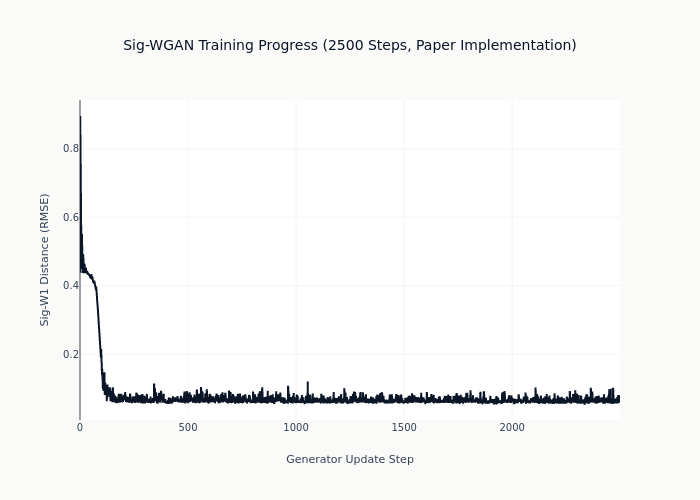


Final Sig-W1 loss: 0.0673
Best Sig-W1 loss: 0.0540
Paper reference: ~2.76 (S&P 500 log returns, 2005-2020)

Using paper-exact data source: S&P 500 index log returns


In [36]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(y=training_losses, mode="lines", name="Sig-W1 Loss", line=dict(color=COLORS["blue"]))
)
fig.update_layout(
    title=f"Sig-WGAN Training Progress ({CONFIG['total_steps']} Steps, Paper Implementation)",
    xaxis_title="Generator Update Step",
    yaxis_title="Sig-W1 Distance (RMSE)",
    template="ml4t",
)
fig.show()

print(f"\nFinal Sig-W1 loss: {training_losses[-1]:.4f}")
print(f"Best Sig-W1 loss: {min(training_losses):.4f}")
print("Paper reference: ~2.76 (S&P 500 log returns, 2005-2020)")
print("\nUsing paper-exact data source: S&P 500 index log returns")

**Interpretation**: The Sig-W1 loss measures the L2 distance between expected
signatures of real and generated paths. A decreasing loss curve confirms the
generator is learning to produce paths whose signature statistics match the
training data. Compare the final value to the paper's reference of ~2.76 on
S&P 500 log returns.

## 9. Generate Synthetic Paths

The LSTM generator produces paths UNCONDITIONALLY - no conditioning on past.
Each call generates a fresh batch of paths from Brownian motion noise.

In [37]:
def generate_paths(
    generator: nn.Module,
    n_samples: int,
    n_lags: int,
    device: torch.device,
) -> np.ndarray:
    """
    Generate synthetic paths (UNCONDITIONAL).

    The generator takes batch_size, n_lags, and device - no conditioning input.

    Args:
        generator: Trained LSTMGenerator
        n_samples: Number of paths to generate
        n_lags: Length of each path
        device: Torch device

    Returns:
        Shape (n_samples, n_lags, n_assets)
    """
    generator.eval()

    with torch.no_grad():
        paths = generator(n_samples, n_lags, device)

    return paths.cpu().numpy()


# Generate synthetic paths
n_synthetic = len(train_windows)  # Match training set size
synthetic_paths = generate_paths(generator, n_synthetic, CONFIG["n_lags"], device)
print(f"Generated {n_synthetic} synthetic paths")
print(f"Synthetic paths shape: {synthetic_paths.shape}")

# Also generate for holdout comparison
n_holdout_gen = len(holdout_windows)
synthetic_holdout = generate_paths(generator, n_holdout_gen, CONFIG["n_lags"], device)
print(f"Generated {n_holdout_gen} synthetic paths for holdout comparison")

Generated 3249 synthetic paths
Synthetic paths shape: (3249, 16, 1)
Generated 592 synthetic paths for holdout comparison


## 10. Evaluation

### 10.1 Fidelity: Visual Comparison with PCA and t-SNE

We project both real and synthetic paths into 2D to assess whether the
generator covers the same regions of the data manifold.

utils/style.py:764: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


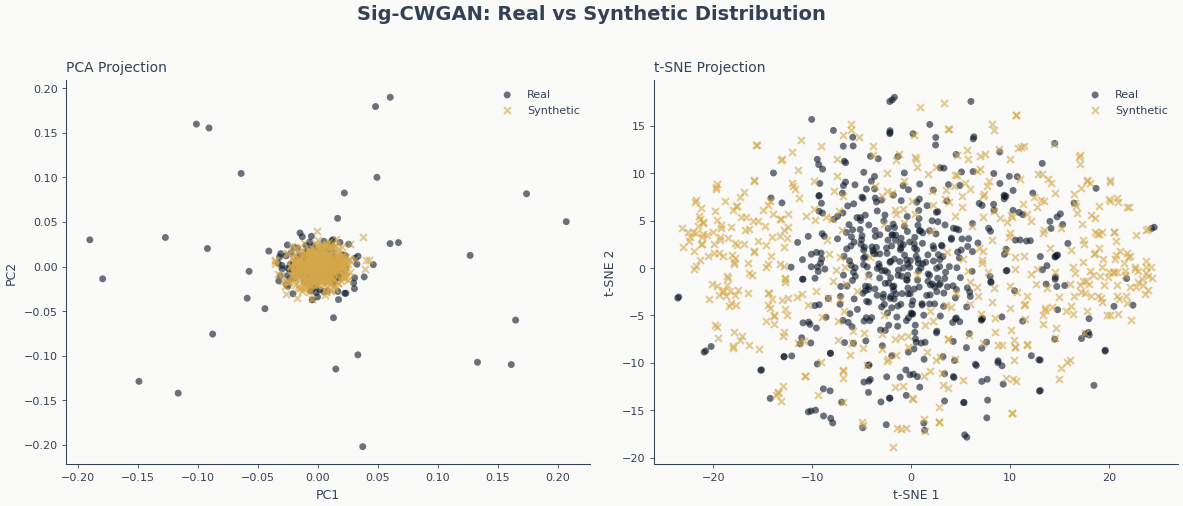

In [38]:
fig = plot_fidelity_comparison(
    holdout_windows,
    synthetic_holdout,
    title="Sig-CWGAN: Real vs Synthetic Distribution",
    n_samples=min(500, len(holdout_windows)),
    flatten_method="flatten",  # Flatten entire path for comparison
)
plt.show()

**Interpretation**: Overlapping point clouds confirm that synthetic paths occupy
the same region of feature space as real data. Sig-CWGAN's strength is capturing
path-wise properties via signatures -- the signature-based metrics below provide
a more rigorous assessment than visual inspection alone.

### 10.2 Compare Signature Distributions

**Paper Evaluation**: Compare expected signatures of real vs synthetic paths.
This is the same metric used for training (Sig-W1).

In [39]:
def evaluate_sig_w1(
    real_paths: np.ndarray,
    synthetic_paths: np.ndarray,
    depth: int,
    config: dict,
    normalise: bool = True,
) -> dict:
    """
    Evaluate using paper's Sig-W1 metric.

    Computes:
    - Sig-W1 distance (expected signature RMSE)
    - Per-coordinate analysis
    - Marginal statistics comparison
    """
    # Compute expected signatures using paper pipeline
    print("Computing real expected signature...")
    real_sigs = compute_signatures_batch_paper(
        real_paths, depth, config, normalise=normalise, desc="Real"
    )
    expected_sig_real = real_sigs.mean(axis=0)

    print("Computing synthetic expected signature...")
    syn_sigs = compute_signatures_batch_paper(
        synthetic_paths, depth, config, normalise=normalise, desc="Synthetic"
    )
    expected_sig_syn = syn_sigs.mean(axis=0)

    # Sig-W1 distance (paper metric)
    sig_w1 = np.sqrt(np.sum((expected_sig_real - expected_sig_syn) ** 2))

    # Per-coordinate analysis
    diff = expected_sig_real - expected_sig_syn
    per_coord_mae = np.abs(diff).mean()
    per_coord_max = np.abs(diff).max()

    # Marginal statistics
    real_mean = real_paths.mean()
    syn_mean = synthetic_paths.mean()
    real_std = real_paths.std()
    syn_std = synthetic_paths.std()

    # KS statistic on marginals
    real_flat = real_paths.flatten()
    syn_flat = synthetic_paths.flatten()
    ks_stat, _ = stats.ks_2samp(real_flat, syn_flat)

    return {
        "sig_w1": sig_w1,
        "per_coord_mae": per_coord_mae,
        "per_coord_max": per_coord_max,
        "sig_dim": len(expected_sig_real),
        "ks_statistic": ks_stat,
        "real_mean": real_mean,
        "syn_mean": syn_mean,
        "real_std": real_std,
        "syn_std": syn_std,
    }

In [40]:
# Evaluate on holdout data
print("\n=== Sig-W1 Evaluation (Holdout Data) ===")
eval_results = evaluate_sig_w1(
    holdout_windows,
    synthetic_holdout,
    CONFIG["sig_depth"],
    CONFIG,
    normalise=CONFIG["normalise_sig"],
)

print("\n--- Results ---")
print(f"Sig-W1 Distance: {eval_results['sig_w1']:.4f}")
print("  (Paper reference: ~2.76 on S&P 500 log returns)")
print(f"Signature dimension: {eval_results['sig_dim']}")
print(f"Per-coordinate MAE: {eval_results['per_coord_mae']:.6f}")
print(f"Per-coordinate Max Error: {eval_results['per_coord_max']:.6f}")
print("\nMarginal Statistics:")
print(f"  Real mean: {eval_results['real_mean']:.6f}, std: {eval_results['real_std']:.6f}")
print(f"  Synth mean: {eval_results['syn_mean']:.6f}, std: {eval_results['syn_std']:.6f}")
print(f"  KS statistic: {eval_results['ks_statistic']:.4f}")


=== Sig-W1 Evaluation (Holdout Data) ===
Computing real expected signature...


Real:   0%|          | 0/592 [00:00<?, ?it/s]

Real: 100%|██████████| 592/592 [00:00<00:00, 9854.18it/s]

Computing synthetic expected signature...


Synthetic:   0%|          | 0/592 [00:00<?, ?it/s]

Synthetic: 100%|██████████| 592/592 [00:00<00:00, 9991.78it/s]


--- Results ---
Sig-W1 Distance: 0.4200
  (Paper reference: ~2.76 on S&P 500 log returns)
Signature dimension: 780
Per-coordinate MAE: 0.004960
Per-coordinate Max Error: 0.122825

Marginal Statistics:
  Real mean: 0.000109, std: 0.015508
  Synth mean: 0.000530, std: 0.014002
  KS statistic: 0.1172


### Signature Analysis: Why Factorial Normalization Matters

Without factorial normalization, signature levels have vastly different scales:
- Level 1: O(1) magnitude
- Level 2: O(1/2!) magnitude
- Level 3: O(1/3!) magnitude
- Level 4: O(1/4!) magnitude

The paper multiplies each level by k! to bring them to comparable scales.

In [41]:
# Diagnostic: Signature level analysis
print("\n=== Signature Level Analysis ===")

# Get expected signatures (already computed)
real_sigs_sample = compute_signatures_batch_paper(
    holdout_windows[:100],
    CONFIG["sig_depth"],
    CONFIG,
    normalise=CONFIG["normalise_sig"],
    desc="Sample",
)
syn_sigs_sample = compute_signatures_batch_paper(
    synthetic_holdout[:100],
    CONFIG["sig_depth"],
    CONFIG,
    normalise=CONFIG["normalise_sig"],
    desc="Sample",
)

# Analyze by signature level
path_dim = compute_path_dim_paper(n_assets)
print(f"Path dimension after augmentations: {path_dim}")

count = 0
for level in range(1, CONFIG["sig_depth"] + 1):
    level_size = path_dim**level
    level_real = real_sigs_sample[:, count : count + level_size]
    level_syn = syn_sigs_sample[:, count : count + level_size]

    real_mag = np.abs(level_real).mean()
    syn_mag = np.abs(level_syn).mean()
    level_error = np.abs(level_real.mean(0) - level_syn.mean(0)).mean()

    print(f"\nLevel {level} ({level_size} dims):")
    print(f"  Real magnitude: {real_mag:.4f}")
    print(f"  Synth magnitude: {syn_mag:.4f}")
    print(f"  Mean error: {level_error:.4f}")
    print(f"  Factorial factor: {math.factorial(level)}")

    count += level_size


=== Signature Level Analysis ===


Sample:   0%|          | 0/100 [00:00<?, ?it/s]

Sample: 100%|██████████| 100/100 [00:00<00:00, 9374.84it/s]

Sample:   0%|          | 0/100 [00:00<?, ?it/s]

Sample: 100%|██████████| 100/100 [00:00<00:00, 9621.51it/s]

Path dimension after augmentations: 5

Level 1 (5 dims):
  Real magnitude: 0.6064
  Synth magnitude: 0.6095
  Mean error: 0.0003
  Factorial factor: 1

Level 2 (25 dims):
  Real magnitude: 0.3743
  Synth magnitude: 0.3754
  Mean error: 0.0011
  Factorial factor: 2

Level 3 (125 dims):
  Real magnitude: 0.2353
  Synth magnitude: 0.2334
  Mean error: 0.0017
  Factorial factor: 6

Level 4 (625 dims):
  Real magnitude: 0.1494
  Synth magnitude: 0.1463
  Mean error: 0.0020
  Factorial factor: 24


## 11. Visualization: Real vs Synthetic Paths

Compare the distributional properties of real and synthetic paths.

In [42]:
def plot_path_comparison_unconditional(
    real_paths: np.ndarray,
    synthetic_paths: np.ndarray,
    n_samples: int = 20,
    asset_idx: int = 0,
) -> go.Figure:
    """Compare distributions of real and synthetic paths."""
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["Real Paths", "Synthetic Paths"],
        shared_yaxes=True,
    )

    # Convert to cumsum for visualization
    n_lags = real_paths.shape[1]

    real_cumsums = np.stack(
        [real_paths[i, :, asset_idx].cumsum() for i in range(min(n_samples, len(real_paths)))]
    )
    synth_cumsums = np.stack(
        [
            synthetic_paths[i, :, asset_idx].cumsum()
            for i in range(min(n_samples, len(synthetic_paths)))
        ]
    )

    # Plot real paths
    for i, cumsum_path in enumerate(real_cumsums):
        fig.add_trace(
            go.Scatter(
                x=list(range(n_lags)),
                y=cumsum_path,
                mode="lines",
                line=dict(color=COLORS["blue"], width=0.5),
                opacity=0.3,
                showlegend=(i == 0),
                name="Real" if i == 0 else None,
            ),
            row=1,
            col=1,
        )

    # Plot synthetic paths
    for i, cumsum_path in enumerate(synth_cumsums):
        fig.add_trace(
            go.Scatter(
                x=list(range(n_lags)),
                y=cumsum_path,
                mode="lines",
                line=dict(color=COLORS["copper"], width=0.5),
                opacity=0.3,
                showlegend=(i == 0),
                name="Synthetic" if i == 0 else None,
            ),
            row=1,
            col=2,
        )

    # Shared y-axis range so visual spread is comparable across panels
    y_lo = float(min(real_cumsums.min(), synth_cumsums.min()))
    y_hi = float(max(real_cumsums.max(), synth_cumsums.max()))
    pad = 0.05 * (y_hi - y_lo if y_hi > y_lo else 1.0)
    shared_range = [y_lo - pad, y_hi + pad]

    fig.update_layout(
        title=f"Sig-WGAN: Path Comparison (Asset {asset_idx})",
        template="ml4t",
        height=400,
        yaxis=dict(range=shared_range),
        yaxis2=dict(range=shared_range),
    )
    fig.update_xaxes(title_text="Day", row=1, col=1)
    fig.update_xaxes(title_text="Day", row=1, col=2)
    fig.update_yaxes(title_text="Cumulative Return", row=1, col=1)

    return fig

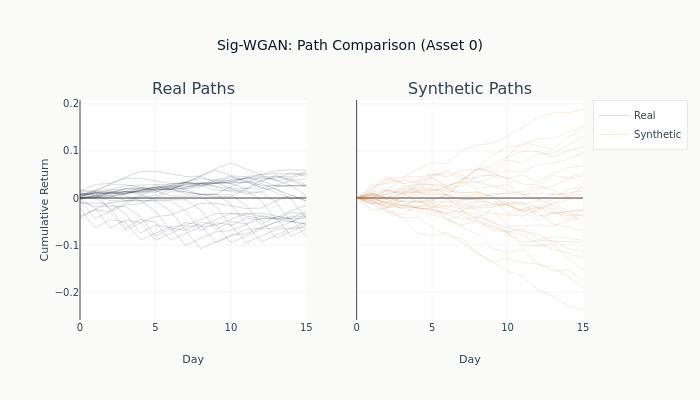

In [43]:
# Plot comparison
fig = plot_path_comparison_unconditional(
    holdout_windows, synthetic_holdout, n_samples=30, asset_idx=0
)
fig.show()

**Interpretation**: Both panels should show paths with similar volatility
and drift characteristics. Synthetic paths that are too smooth or too volatile
indicate the generator has not fully captured the return distribution.
The cumulative sum visualization amplifies differences: look for matching
spread (volatility) and symmetry around zero (mean accuracy).

## 12. TSTR Evaluation: Train Synthetic, Test Real

TSTR (Train Synthetic, Test Real) measures whether a model trained on
synthetic data can predict real outcomes as well as a model trained on
real data.

For unconditional generation, we use a next-step prediction task.

In [44]:
def tstr_evaluation_unconditional(
    real_train: np.ndarray,
    real_holdout: np.ndarray,
    synthetic_train: np.ndarray,
) -> dict:
    """
    TSTR evaluation for unconditional generation.

    Task: Predict sign of next return from path features.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    # Feature engineering: use path statistics as features
    def extract_features(paths):
        """Extract statistical features from paths."""
        features = []
        for path in paths:
            # Rolling statistics
            feat = [
                path.mean(),
                path.std(),
                path[-1, 0] - path[0, 0],  # Total return asset 0
                path[-1, 1] - path[0, 1] if path.shape[1] > 1 else 0,  # Asset 1
                np.corrcoef(path[:, 0], path[:, 1])[0, 1] if path.shape[1] > 1 else 0,
            ]
            features.append(feat)
        return np.array(features)

    # Extract labels: sign of last return
    def extract_labels(paths):
        """Label: was last return positive?"""
        return (paths[:, -1, 0] > 0).astype(int)

    # Prepare data
    X_real_train = extract_features(real_train)
    y_real_train = extract_labels(real_train)

    X_syn_train = extract_features(synthetic_train)
    y_syn_train = extract_labels(synthetic_train)

    X_test = extract_features(real_holdout)
    y_test = extract_labels(real_holdout)

    # Handle NaN in correlation features
    X_real_train = np.nan_to_num(X_real_train, nan=0.0)
    X_syn_train = np.nan_to_num(X_syn_train, nan=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0)

    # Scale features
    scaler = StandardScaler()
    X_real_train_scaled = scaler.fit_transform(X_real_train)
    X_syn_train_scaled = scaler.transform(X_syn_train)
    X_test_scaled = scaler.transform(X_test)

    # Train on real, test on holdout (baseline)
    model_real = LogisticRegression(max_iter=1000)
    model_real.fit(X_real_train_scaled, y_real_train)
    acc_real = model_real.score(X_test_scaled, y_test)

    # Train on synthetic, test on holdout (TSTR)
    n_classes_syn = len(np.unique(y_syn_train))
    if n_classes_syn < 2:
        majority_class = int(y_syn_train.mean() > 0.5)
        acc_syn = (y_test == majority_class).mean()
        print(f"Warning: Synthetic data has only {n_classes_syn} class, using majority vote")
    else:
        model_syn = LogisticRegression(max_iter=1000)
        model_syn.fit(X_syn_train_scaled, y_syn_train)
        acc_syn = model_syn.score(X_test_scaled, y_test)

    return {
        "accuracy_train_real": acc_real,
        "accuracy_train_synthetic": acc_syn,
        "tstr_ratio": acc_syn / acc_real if acc_real > 0 else 0,
        "n_train_samples": len(y_real_train),
        "n_test_samples": len(y_test),
    }

In [45]:
tstr_results = tstr_evaluation_unconditional(train_windows, holdout_windows, synthetic_paths)

print("\n=== TSTR Evaluation (Holdout Test Set) ===")
print("Task: Predict sign of last return from path features")
print(f"Training samples: {tstr_results['n_train_samples']}")
print(f"Test samples: {tstr_results['n_test_samples']}")
print(f"Accuracy (trained on REAL): {tstr_results['accuracy_train_real']:.4f}")
print(f"Accuracy (trained on SYNTHETIC): {tstr_results['accuracy_train_synthetic']:.4f}")
print(f"TSTR Ratio: {tstr_results['tstr_ratio']:.4f}")
print("\n(TSTR ratio near 1.0 indicates synthetic data preserves predictive utility)")


=== TSTR Evaluation (Holdout Test Set) ===
Task: Predict sign of last return from path features
Training samples: 3249
Test samples: 592
Accuracy (trained on REAL): 0.7686
Accuracy (trained on SYNTHETIC): 0.7331
TSTR Ratio: 0.9538

(TSTR ratio near 1.0 indicates synthetic data preserves predictive utility)


**Interpretation**: A TSTR ratio near 1.0 means a classifier trained on
synthetic data performs as well on real holdout data as one trained on actual
data. For return-sign prediction (a near-random task), ratios close to 1.0
are expected even with moderate generation quality. The key diagnostic is
whether the synthetic-trained model significantly underperforms the
real-trained baseline.

## 13. Summary Visualization

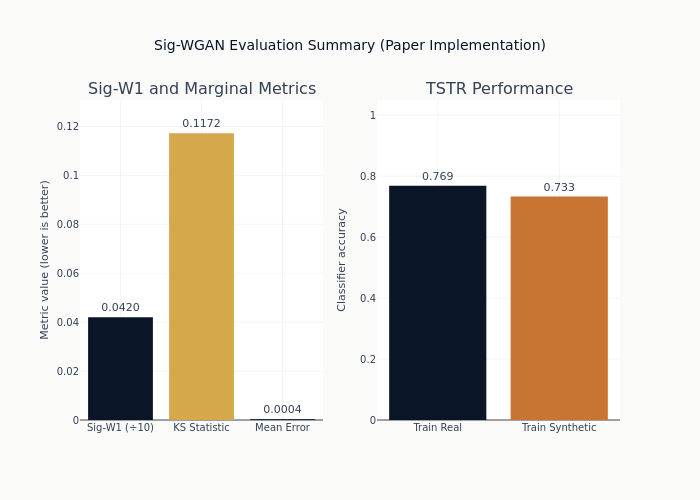

In [46]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Sig-W1 and Marginal Metrics", "TSTR Performance"],
)

# Left: Signature and marginal metrics
metrics = ["Sig-W1 (÷10)", "KS Statistic", "Mean Error"]
values = [
    eval_results["sig_w1"] / 10,  # Scale down for visualization
    eval_results["ks_statistic"],
    abs(eval_results["real_mean"] - eval_results["syn_mean"]),
]

fig.add_trace(
    go.Bar(
        x=metrics,
        y=values,
        marker_color=[COLORS["blue"], COLORS["amber"], COLORS["slate"]],
        text=[f"{v:.4f}" for v in values],
        textposition="outside",
    ),
    row=1,
    col=1,
)

# Right: TSTR
methods = ["Train Real", "Train Synthetic"]
accuracies = [
    tstr_results["accuracy_train_real"],
    tstr_results["accuracy_train_synthetic"],
]

fig.add_trace(
    go.Bar(
        x=methods,
        y=accuracies,
        marker_color=[COLORS["blue"], COLORS["copper"]],
        text=[f"{a:.3f}" for a in accuracies],
        textposition="outside",
    ),
    row=1,
    col=2,
)

fig.update_yaxes(title_text="Metric value (lower is better)", row=1, col=1)
fig.update_yaxes(title_text="Classifier accuracy", row=1, col=2, range=[0, 1.05])
fig.update_layout(
    title_text="Sig-WGAN Evaluation Summary (Paper Implementation)",
    showlegend=False,
    template="ml4t",
)

fig.show()

**Interpretation**: The left panel reports three distributional checks - the
signature-level Sig-W1 distance (scaled down by 10 for visual co-display), the
marginal Kolmogorov-Smirnov statistic, and the absolute mean-error between real
and synthetic samples. A near-zero Mean Error bar is good news (centred
generation), not a missing value - the bar is small because the generator has
learned the marginal location. The right panel reports TSTR: classifier
accuracy when trained on real vs synthetic. The two bars should sit at similar
heights for utility preservation; a gap exceeding ~0.05 indicates the
synthetic data is missing discriminative structure.

## 13b. Additional Evaluation Metrics

Beyond Sig-W1, we evaluate:
- Autocorrelation structure (ACF)
- Cross-asset correlation
- Stylized facts (kurtosis, skewness)

In [47]:
def compute_stylized_facts(paths: np.ndarray) -> dict:
    """Compute stylized facts of financial returns."""
    # Flatten to get marginal distribution
    returns = paths.flatten()

    # Basic statistics
    mean = np.mean(returns)
    std = np.std(returns)
    skew = stats.skew(returns)
    kurt = stats.kurtosis(returns)

    # ACF of returns and squared returns
    def acf(x, nlags=10):
        """Simple ACF computation."""
        result = []
        x_centered = x - x.mean()
        var = np.var(x)
        for lag in range(nlags + 1):
            if lag == 0:
                result.append(1.0)
            else:
                result.append(np.corrcoef(x_centered[:-lag], x_centered[lag:])[0, 1])
        return np.array(result)

    acf_returns = acf(returns, nlags=5)
    acf_squared = acf(returns**2, nlags=5)

    return {
        "mean": mean,
        "std": std,
        "skewness": skew,
        "kurtosis": kurt,
        "acf_returns_lag1": acf_returns[1] if len(acf_returns) > 1 else np.nan,
        "acf_squared_lag1": acf_squared[1] if len(acf_squared) > 1 else np.nan,
    }


print("=" * 70)
print("STYLIZED FACTS COMPARISON")
print("=" * 70)

real_facts = compute_stylized_facts(holdout_windows)
syn_facts = compute_stylized_facts(synthetic_holdout)

print("\n{:<25} {:>12} {:>12}".format("Metric", "Real", "Synthetic"))
print("-" * 50)
for key in real_facts:
    print(f"{key:<25} {real_facts[key]:>12.4f} {syn_facts[key]:>12.4f}")

# Cross-correlation comparison
if n_assets >= 2:
    real_corr = np.corrcoef(holdout_windows[:, :, 0].flatten(), holdout_windows[:, :, 1].flatten())[
        0, 1
    ]
    syn_corr = np.corrcoef(
        synthetic_holdout[:, :, 0].flatten(), synthetic_holdout[:, :, 1].flatten()
    )[0, 1]
    print(f"\nCross-asset correlation: Real={real_corr:.4f}, Synth={syn_corr:.4f}")

STYLIZED FACTS COMPARISON

Metric                            Real    Synthetic
--------------------------------------------------
mean                            0.0001       0.0005
std                             0.0155       0.0140
skewness                       -0.9278      -0.0033
kurtosis                       16.2203       0.2279
acf_returns_lag1               -0.2570       0.1929
acf_squared_lag1                0.4949       0.0512


**Interpretation**: Key stylized facts to check: (1) kurtosis should be >3
(fat tails), matching the well-known leptokurtic property of financial returns;
(2) negative skewness reflects asymmetric crash risk; (3) near-zero lag-1 ACF
of returns but positive lag-1 ACF of squared returns captures volatility
clustering. Large deviations in any metric indicate the generator misses
important market microstructure.

## 14. Save Outputs

In [48]:
# Output directory
output_dir = get_output_dir(5, "sigcwgan")
checkpoint_subdir = "checkpoints"
checkpoint_dir = output_dir / checkpoint_subdir / "sigwgan_paper" / f"depth{CONFIG['sig_depth']}"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Save model checkpoint
checkpoint = {
    "generator": generator.state_dict(),
    "expected_sig_real": expected_sig_real,
    "train_mean": train_mean.tolist(),  # For reference only (no normalization used)
    "train_std": train_std.tolist(),  # For reference only (no normalization used)
}
torch.save(checkpoint, checkpoint_dir / "checkpoint.pt")

In [49]:
# Save metadata — core fields
metadata = {
    "version": "2.0",  # Paper-exact implementation
    "generator": {
        "name": "sigwgan_paper",
        "architecture": "LSTMGenerator",
        "paper": "Ni et al., Sig-Wasserstein GANs for Time Series Generation, Mathematical Finance 2024",
    },
    "training": {
        "created_at": datetime.now(UTC).isoformat(),
        "device": str(device),
        "random_seed": 42,
        "final_loss": float(training_losses[-1]),
        "best_loss": float(min(training_losses)),
    },
    "data": {
        "source": "sp500_index",
        "description": "S&P 500 daily log returns (paper-exact)",
        "start_date": CONFIG["start_date"],
        "end_date": CONFIG.get("end_date", "present"),
        "holdout_start": CONFIG["holdout_start"],
        "n_lags": int(CONFIG["n_lags"]),
        "n_features": int(n_assets),
        "n_total_days": int(n_total_days),
        "n_train_windows": int(len(train_windows)),
        "n_holdout_windows": int(len(holdout_windows)),
        "split_method": "temporal_at_date",
    },
    "normalization": {
        "method": "none",
        "note": "Paper uses raw log returns without normalization",
        "train_mean": train_mean.tolist(),
        "train_std": train_std.tolist(),
    },
}

In [50]:
# Save metadata — hyperparameters, augmentation spec, and evaluation results
metadata["hyperparameters"] = {
    "sig_depth": int(CONFIG["sig_depth"]),
    "lstm_hidden_dim": int(CONFIG["lstm_hidden_dim"]),
    "lstm_n_layers": int(CONFIG["lstm_n_layers"]),
    "noise_dim": int(CONFIG["noise_dim"]),
    "total_steps": int(CONFIG["total_steps"]),
    "batch_size": int(CONFIG["batch_size"]),
    "learning_rate": float(CONFIG["learning_rate"]),
    "lr_scheduler_step": int(CONFIG["lr_scheduler_step"]),
    "lr_scheduler_gamma": float(CONFIG["lr_scheduler_gamma"]),
    "normalise_sig": bool(CONFIG["normalise_sig"]),
}
metadata["augmentation_pipeline"] = [
    {"name": "Scale", "scale": CONFIG["scale_factor"], "dim": CONFIG["scale_dim"]},
    {"name": "AddTime"},
    {"name": "LeadLag"},
    {"name": "VisiTrans", "type": "I"},
]
metadata["signature_spec"] = {
    "depth": int(CONFIG["sig_depth"]),
    "path_dim": compute_path_dim_paper(n_assets),
    "sig_dim": compute_sig_dim_paper(n_assets, CONFIG["sig_depth"]),
    "factorial_normalization": bool(CONFIG["normalise_sig"]),
}
metadata["evaluation"] = {
    "sig_w1": float(eval_results["sig_w1"]),
    "ks_statistic": float(eval_results["ks_statistic"]),
    "tstr_ratio": float(tstr_results["tstr_ratio"]),
    "paper_reference_sig_w1": 2.76,  # For comparison
}

with open(checkpoint_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [51]:
# Save pre-generated samples (already in log return scale, no denormalization needed)
np.save(checkpoint_dir / "samples.npy", synthetic_paths.astype(np.float32))

print("\nSample statistics (log returns scale):")
print(f"  Mean: {synthetic_paths.mean():.6f}, Std: {synthetic_paths.std():.6f}")
print(f"  Range: [{synthetic_paths.min():.6f}, {synthetic_paths.max():.6f}]")

# Save holdout data for external evaluation
np.save(checkpoint_dir / "holdout_returns.npy", holdout_returns_original)
np.save(checkpoint_dir / "train_returns.npy", returns_original)

print("\nSaved outputs to:")
print(f"  {checkpoint_dir}/")


Sample statistics (log returns scale):
  Mean: 0.000365, Std: 0.013708
  Range: [-0.065317, 0.055378]

Saved outputs to:
  05_synthetic_data/output/sigcwgan/checkpoints/sigwgan_paper/depth4/


## Key Takeaways

**What Sig-WGAN Offers**:

1. **No Adversarial Training**: The "discriminator" is the expected signature,
   eliminating mode collapse and training instability

2. **Principled Distance**: Path signatures provide a mathematically rigorous
   way to compare time series distributions

3. **Factorial Normalization**: Rescales signature levels to comparable magnitudes,
   critical for stable training and meaningful loss values

**PAPER-EXACT Implementation** (Ni et al., Mathematical Finance 2024):

1. **Generator**: LSTMGenerator with Brownian motion noise input
   - NOT AR-FNN with independent Gaussian noise
   - Noise: `z = 0.1 * randn(...).cumsum(1)` (Brownian path)

2. **Augmentations**: Scale(2,0) → AddTime → LeadLag → VisiTrans("I")
   - NOT cumsum_concat → lag_added → lead_lag
   - Critical: VisiTrans adds 2 rows + 1 column

3. **Factorial Normalization**: Level k terms multiplied by k!
   - Without this, higher levels have tiny magnitudes
   - Paper: `sig[count:count+dim**(i+1)] *= factorial(i+1)`

4. **Hyperparameters**: batch=2000, depth=4, lr=1e-3, steps=2500
   - Scheduler: StepLR(128, 0.95)

5. **Loss**: RMSE (L2 norm), NOT squared MSE
   - `loss = sqrt(sum((sig_fake - sig_real)**2))`

**Paper-Exact Data Source**:

This implementation now uses the SAME data as the paper:
- S&P 500 index daily close prices (paper used Oxford MAN, now defunct)
- Log returns: `log(close_t) - log(close_{t-1})`
- Single asset (paper's `.SPX`)
- Period: 2005-01-01 to 2020-06-01

**Paper reference values** (Ni et al., 2024, on S&P 500 log returns):

| Metric | Paper Reference |
|--------|-----------------|
| Sig-W1 | ~2.76           |
| TSTR   | ~1.0            |

The Sig-W1 scale depends on signature depth, augmentation choices, and the
magnitude of the input series, so direct numeric comparison to the paper is
only meaningful when those settings match. The values printed above in the
evaluation cell are the achieved metrics on the run in this notebook.

**Limitations**:

1. **Signature Cost**: O(d^depth) where d = path dimension after augmentations
2. **Small Universe**: 1-5 assets max at depth 4 (exponential scaling)
3. **Single Asset**: Paper only demonstrates on single-asset time series